Spectometric data: Classifying high vs. low fat meat using derivatives and scalar features
=========================================================================

Binary classification of meat samples as high or low-fat based on their 
infrared spectrometric curves and associated scalar features.



In this example, we classify meat samples into two categories: **low fat**
(less than 20% fat content) and **high fat** (20% or more) using:
- The original spectrometric infrared curves (functional data)
- Their first and second derivatives
- Scalar variables: water and protein content

These data come from the Tecator dataset, a popular benchmark in functional
data analysis.

In [1]:
from skfda.datasets import fetch_tecator

X_df, y_df = fetch_tecator(return_X_y=True, as_frame=True)

fd = X_df.iloc[:, 0].array
fat = y_df["fat"].to_numpy()
water = y_df["water"].to_numpy()
protein = y_df["protein"].to_numpy()

We define the target labels for classification. Samples with less than 20%
fat are labeled as "low fat", and the rest as "high fat".

In [ ]:
from skfda.exploratory import stats
from skfda.exploratory.stats import grand_mean, root_mean_square_l2
from skfda.misc.metrics import default_metric, l2_distance

# Macros:
fat_threshold = 25
center = stats.mean
scale = stats.std
features = ["original", "derivative", "protein"]
metrics = [
    l2_distance,
    l2_distance,
    default_metric,
]
n_neighbors = 5
random_state_split = 1
test_size = 0.25
optimize_weights = False
n_samples_random_search = 1000
best_weights = [1, 1, 1]

In [3]:
import numpy as np

low_fat = fat < fat_threshold
labels = np.where(low_fat, "low fat", "high fat")
y = np.where(low_fat, 0, 1)  # 0 = low fat, 1 = high fat (binary label)

We plot the original spectrometric curves, grouped by fat content.

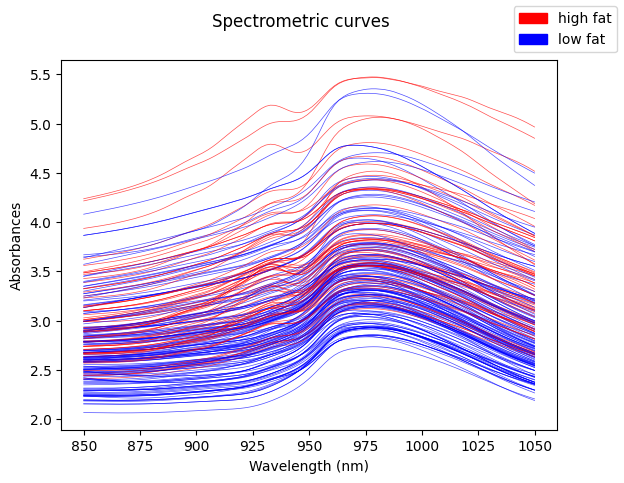

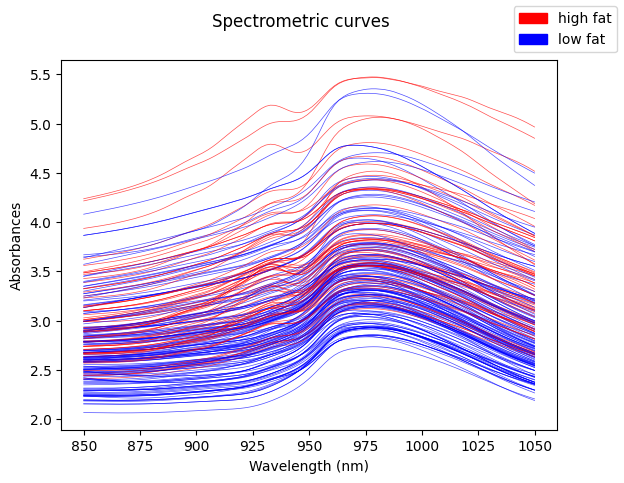

In [4]:
import matplotlib.pyplot as plt

colors = {
    "high fat": "red",
    "low fat": "blue",
}

fd.plot(
    group=labels,
    group_colors=colors,
    linewidth=0.5,
    alpha=0.7,
    legend=True,
)

We also visualize the first and second derivatives.

In spectrometric data, much of the relevant discriminative information lies not in the absolute levels of absorbance but in the shape and variation of the spectra. As highlighted in Ferraty and Vieu (Chapter 7), derivatives often capture subtle local features, such as slope changes and inflection points, that are associated with underlying chemical properties. In our case, the first and second derivatives help emphasize these local variations, making it easier to distinguish between samples with different fat content.

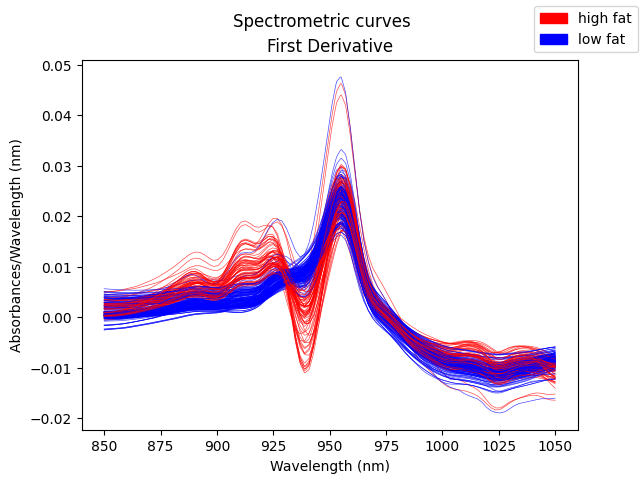

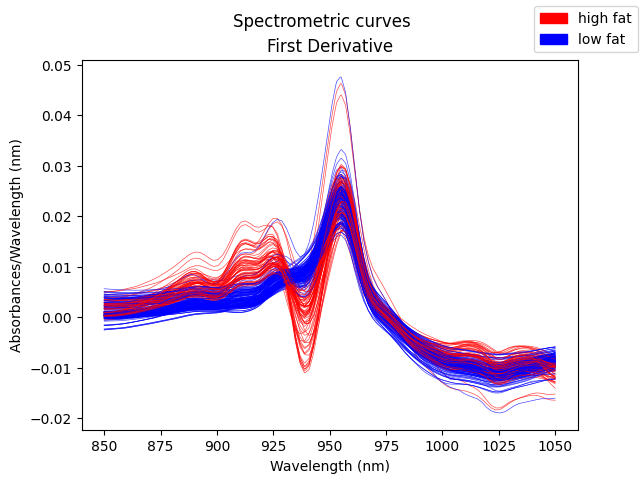

In [5]:
fd_1st = fd.derivative()
fd_2nd = fd_1st.derivative()

fd_1st.coordinate_names = ("Absorbances/Wavelength (nm)",)

fig, ax = plt.subplots()

fd_1st.plot(
    group=labels,
    group_colors=colors,
    linewidth=0.5,
    alpha=0.7,
    legend=True,
    axes=ax,
)

ax.set_title("First Derivative")
fig

We also inspect the scalar features (water and protein percentages), which
may help in distinguishing the two fat groups.

In [6]:
import pandas as pd

df_scalar = pd.DataFrame(
    {
        "water": water,
        "protein": protein,
        "fat_group": labels,
    },
)

print(df_scalar.groupby("fat_group").describe())

           water                                                        \
           count       mean       std   min     25%    50%   75%   max   
fat_group                                                                
high fat    66.0  50.392424  5.833202  39.3  45.175  51.55  55.4  60.6   
low fat    149.0  68.879530  4.607060  55.3  65.600  69.80  72.5  76.6   

          protein                                                        
            count      mean       std   min     25%   50%     75%   max  
fat_group                                                                
high fat     66.0  14.29697  1.970628  11.0  13.125  14.4  15.475  19.2  
low fat     149.0  19.18255  2.019022  11.5  18.400  19.5  20.500  21.8  


Train-test split and assembling the full dataset
------------------------------------------------
We now divide our dataset into training and testing partitions. We split all
functional components (original spectrum, first derivative, second derivative),
as well as the scalar variables (water and protein), in a stratified fashion
to preserve the proportion of low- and high-fat samples.

In [7]:
from sklearn.model_selection import train_test_split

(
    fd_train,
    fd_test,
    fd_1st_train,
    fd_1st_test,
    fd_2nd_train,
    fd_2nd_test,
    water_train,
    water_test,
    protein_train,
    protein_test,
    y_train,
    y_test,
) = train_test_split(
    fd,
    fd_1st,
    fd_2nd,
    water,
    protein,
    y,
    test_size=test_size,
    stratify=y,
    random_state=random_state_split,
)

Scaling
-------

When working with vector-valued functional data, particularly when combining a function with its derivatives, applying an appropriate scaling procedure is crucial to ensure that each component contributes meaningfully to any distance-based analysis.

This need becomes especially clear when incorporating derivatives. As is well known in functional data analysis, differentiation tends to amplify local fluctuations and reduce the range of the signal, significantly altering its scale. Even if all components—such as a function and its first and second derivatives—are derived from the same underlying process, their norms can differ by several orders of magnitude. If left unscaled, this imbalance will cause the more variable components to dominate the overall distance computation.

For example, in our dataset, the original function ranges between 2 and 5, the first derivative varies between approximately -0.02 and 0.05, and the second derivative oscillates between -0.004 and 0.003. Despite originating from the same phenomenon, the second derivative's much smaller range and higher oscillatory behavior would disproportionately influence distance-based methods such as k-nearest neighbors or clustering unless scaling is applied beforehand.

To address this, we apply **Root Mean Square (RMS) L2 norm** scaling. This
method rescales each component by the square root of its average squared
norm across the sample, equalizing their overall contribution.

In [8]:
from skfda.preprocessing.scaler import CenterScaler

fd_train_scaled = CenterScaler(center=center, scale=scale).fit_transform(
    fd_train,
)
fd_1st_train_scaled = CenterScaler(center=center, scale=scale).fit_transform(
    fd_1st_train,
)

fd_test_scaled = CenterScaler(center=center, scale=scale).fit_transform(
    fd_test,
)
fd_1st_test_scaled = CenterScaler(center=center, scale=scale).fit_transform(
    fd_1st_test,
)

After applying RMS L2 scaling, the magnitudes of all three components
(the original curves, the first derivative, and the second derivative)
are now brought to a comparable range.

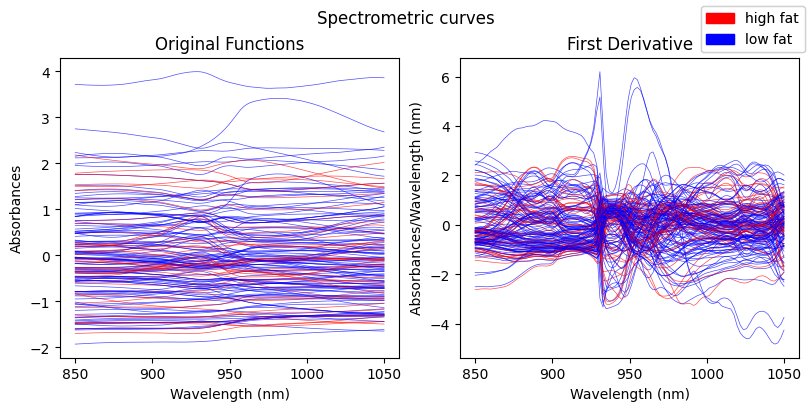

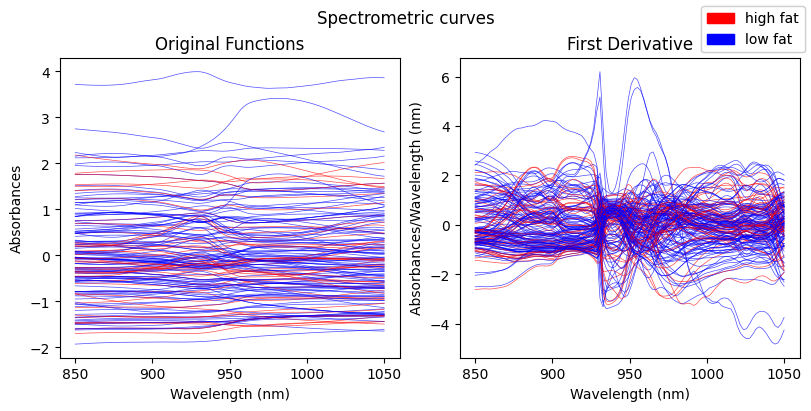

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

fd_train_scaled.plot(
    group=labels,
    group_colors=colors,
    linewidth=0.5,
    alpha=0.7,
    legend=True,
    axes=ax1,
)
ax1.set_title("Original Functions")

fd_1st_train_scaled.plot(
    group=labels,
    group_colors=colors,
    linewidth=0.5,
    alpha=0.7,
    legend=True,
    axes=ax2,
)
ax2.set_title("First Derivative")

fig


In [10]:
from sklearn.preprocessing import StandardScaler as SklearnStandardScaler

scaler = SklearnStandardScaler()
scalar_features_train = scaler.fit_transform(
    np.column_stack([water_train, protein_train]),
)
scalar_features_test = scaler.fit_transform(
    np.column_stack([water_test, protein_test]),
)

Now we combine all inputs into  pandas DataFrames, which allow us to work
with mixed data. Each row corresponds to a sample,
and the columns include the three functional components and two scalar ones.

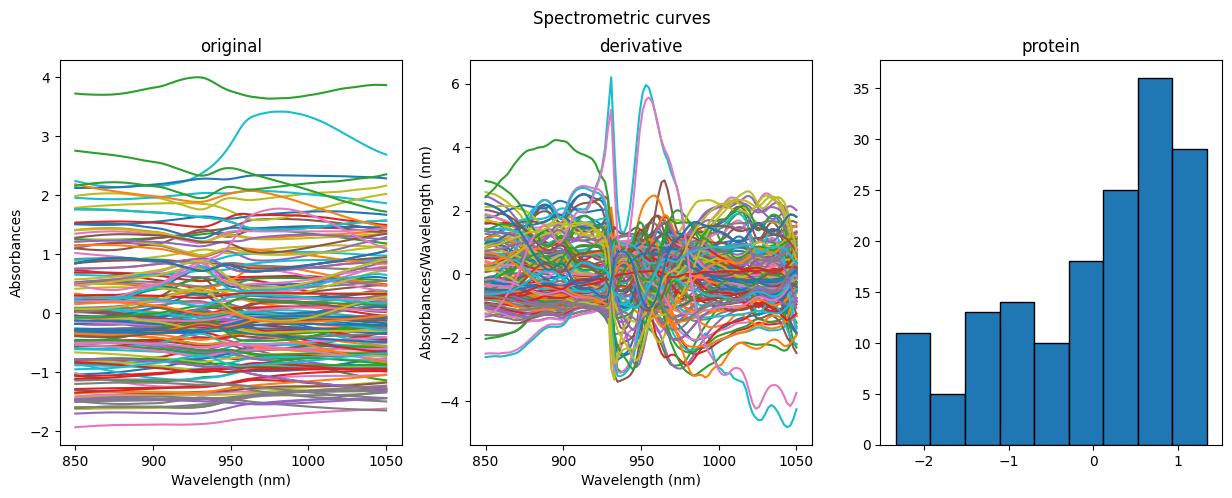

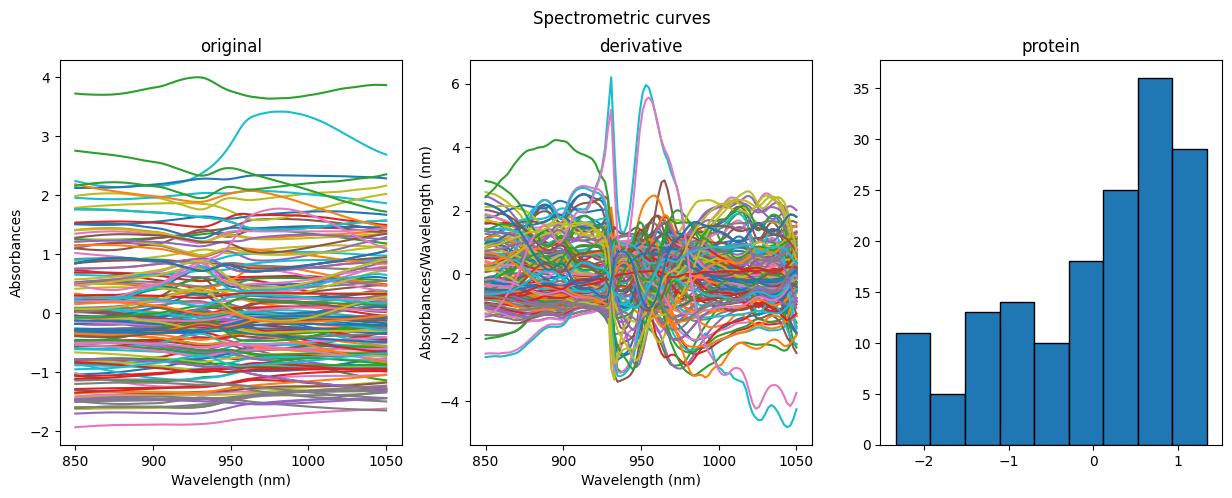

In [11]:
from skfda.exploratory.visualization.representation import plot_mixed_data

train_data = {
    "original": fd_train_scaled,
    "derivative": fd_1st_train_scaled,
    "water": scalar_features_train[:, 0],
    "protein": scalar_features_train[:, 1],
}

test_data = {
    "original": fd_test_scaled,
    "derivative": fd_1st_test_scaled,
    "water": scalar_features_test[:, 0],
    "protein": scalar_features_test[:, 1],
}

X_train = pd.DataFrame({f: train_data[f] for f in features})
X_test = pd.DataFrame({f: test_data[f] for f in features})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_mixed_data(X_train, axes=axes)

Distance metric definition
--------------------------
We define a product metric that combines appropriate distances for each column.
For the functional components we use the $L^2$ distance, and for the scalar features
we use the standard Euclidean distance.

Model fitting and evaluation
----------------------------
We now train the K-nearest neighbors classifier using the product metric and
evaluate its performance on the test set.

In [ ]:
from sklearn.metrics import accuracy_score, make_scorer
from sklearn.model_selection import RandomizedSearchCV

from skfda.misc.metrics import PProductMetric, default_metric, l2_distance
from skfda.ml.classification import KNeighborsClassifier

initial_metric = PProductMetric(
    p=2,
    metrics=[
        l2_distance,
        l2_distance,
        default_metric,
    ],
    weights=np.array([1, 1, 1]),  # initial
)

knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric=initial_metric)

param_distributions = {
    "metric__weights": [
        np.random.dirichlet(np.ones(3))  # uniform over the probability simplex
        for _ in range(n_samples_random_search)  # generate random initial weight vectors
    ],
}

random_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_distributions,
    n_iter=n_samples_random_search,  # number of random samples you want to test
    cv=3,
    scoring=make_scorer(accuracy_score),
    verbose=1,
    random_state=42,
)

if optimize_weights:
    random_search.fit(X_train, y_train)

    print("Best weights:", random_search.best_params_["metric__weights"])
    print("Best CV accuracy:", random_search.best_score_)

    y_pred = random_search.best_estimator_.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test accuracy: {accuracy:.2%}")
    best_weights = random_search.best_params_["metric__weights"]

In [13]:
metric = PProductMetric(
    p=2,
    metrics=[
        l2_distance,
        l2_distance,
        default_metric,
    ],
    weights=best_weights,
)

knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric)
knn.fit(X_train, y_train)

KNeighborsClassifier(('metric', PProductMetric(p=2, weights=[1, 1, 1])))

Finally, we predict and evaluate the accuracy of the model.

In [14]:
from sklearn.metrics import accuracy_score

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 96.30%


Comparison with the model only using the original spectrometric infrared
curves

In [15]:
knn = KNeighborsClassifier(n_neighbors=n_neighbors)
knn.fit(fd_train, y_train)

y_pred = knn.predict(fd_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 74.07%


In [16]:
knn = KNeighborsClassifier(n_neighbors=n_neighbors)
knn.fit(fd_1st_train, y_train)

y_pred = knn.predict(fd_1st_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 96.30%


In [17]:
knn = KNeighborsClassifier(n_neighbors=n_neighbors)
knn.fit(fd_2nd_train, y_train)

y_pred = knn.predict(fd_2nd_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 96.30%


In [18]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
knn.fit(X_train, y_train)
scores = cross_val_score(
    knn,
    X_train,
    y_train,
    cv=cv,
)

mean_score = np.mean(scores)
std_score = np.std(scores)

print(f"Mean score: {mean_score:.3f}")
print(f"Std deviation: {std_score:.3f}")

Mean score: 0.930
Std deviation: 0.041


In [19]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

knn = KNeighborsClassifier(n_neighbors=n_neighbors)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

scores = cross_val_score(knn, fd_train, y_train, cv=cv)

mean_score = np.mean(scores)
std_score = np.std(scores)

print(f"Mean score: {mean_score:.3f}")
print(f"Std deviation: {std_score:.3f}")

Mean score: 0.766
Std deviation: 0.072


In [20]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

knn = KNeighborsClassifier(n_neighbors=n_neighbors)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

scores = cross_val_score(knn, fd_1st_train, y_train, cv=cv)

mean_score = np.mean(scores)
std_score = np.std(scores)

print(f"Mean score: {mean_score:.3f}")
print(f"Std deviation: {std_score:.3f}")

Mean score: 0.963
Std deviation: 0.031


In [21]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

knn = KNeighborsClassifier(n_neighbors=n_neighbors)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

scores = cross_val_score(knn, fd_2nd_train, y_train, cv=cv)

mean_score = np.mean(scores)
std_score = np.std(scores)

print(f"Mean score: {mean_score:.3f}")
print(f"Std deviation: {std_score:.3f}")

Mean score: 0.967
Std deviation: 0.030


This example highlights the value of incorporating multiple components in functional classification models. By combining the original spectrometric curves with their first and second derivatives, as well as scalar features like water and protein content, we significantly improved the classifier’s performance. The accuracy increased from 66.67% using only the raw curves and 94% when using the derivative to over 98% when integrating all components — an improvement of more than 30% and 4% respectively.

In [22]:
from sklearn.neighbors import (
    KNeighborsClassifier as SklearnKNeighborsClassifier,
)

results = {
    "X": [],
    "fd": [],
    "fd_1st": [],
    "fd_2nd": [],
    "protein": [],
}


def results_with_seed(seed: int) -> None:
    X_df, y_df = fetch_tecator(return_X_y=True, as_frame=True)

    fd = X_df.iloc[:, 0].array
    fat = y_df["fat"].to_numpy()
    water = y_df["water"].to_numpy()
    protein = y_df["protein"].to_numpy()

    low_fat = fat < fat_threshold
    labels = np.where(low_fat, "low fat", "high fat")
    y = np.where(low_fat, 0, 1)  # 0 = low fat, 1 = high fat (binary label)

    fd_1st = fd.derivative()
    fd_2nd = fd_1st.derivative()

    fd_1st.coordinate_names = ("Absorbances/Wavelength (nm)",)

    (
        fd_train,
        fd_test,
        fd_1st_train,
        fd_1st_test,
        fd_2nd_train,
        fd_2nd_test,
        water_train,
        water_test,
        protein_train,
        protein_test,
        y_train,
        y_test,
    ) = train_test_split(
        fd,
        fd_1st,
        fd_2nd,
        water,
        protein,
        y,
        test_size=test_size,
        stratify=y,
        random_state=seed,
    )

    scaler = SklearnStandardScaler()
    scalar_features_train = scaler.fit_transform(
        np.column_stack([water_train, protein_train]),
    )
    scalar_features_test = scaler.fit_transform(
        np.column_stack([water_test, protein_test]),
    )

    fd_train_scaled = CenterScaler(center=center, scale=scale).fit_transform(
        fd_train,
    )
    fd_1st_train_scaled = CenterScaler(center=center, scale=scale).fit_transform(
        fd_1st_train,
    )

    fd_test_scaled = CenterScaler(center=center, scale=scale).fit_transform(
        fd_test,
    )
    fd_1st_test_scaled = CenterScaler(center=center, scale=scale).fit_transform(
        fd_1st_test,
    )

    train_data = {
        "original": fd_train_scaled,
        "derivative": fd_1st_train_scaled,
        "water": scalar_features_train[:, 0],
        "protein": scalar_features_train[:, 1],
    }

    test_data = {
        "original": fd_test_scaled,
        "derivative": fd_1st_test_scaled,
        "water": scalar_features_test[:, 0],
        "protein": scalar_features_test[:, 1],
    }

    X_train = pd.DataFrame({f: train_data[f] for f in features})
    X_test = pd.DataFrame({f: test_data[f] for f in features})

    metric = PProductMetric(
        p=2,
        metrics=metrics,
        weights=best_weights,
    )

    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    results["X"].append(accuracy_score(y_test, y_pred))

    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(fd_train, y_train)

    y_pred = knn.predict(fd_test)

    results["fd"].append(accuracy_score(y_test, y_pred))

    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(fd_1st_train, y_train)

    y_pred = knn.predict(fd_1st_test)

    results["fd_1st"].append(accuracy_score(y_test, y_pred))

    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(fd_2nd_train, y_train)

    y_pred = knn.predict(fd_2nd_test)

    results["fd_2nd"].append(accuracy_score(y_test, y_pred))

    protein_df_train = pd.DataFrame({"protein": protein_train})
    protein_df_test = pd.DataFrame({"protein": protein_test})
    knn = SklearnKNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(protein_df_train, y_train)
    y_pred = knn.predict(protein_df_test)
    results["protein"].append(accuracy_score(y_test, y_pred))


In [23]:
for i in range(100):
    results_with_seed(i)

# Summarize
for key in results:
    accs = np.array(results[key])
    print(f"{key}: {accs.mean():.3f} ± {accs.std():.3f}")

X: 0.944 ± 0.029
fd: 0.766 ± 0.054
fd_1st: 0.969 ± 0.021
fd_2nd: 0.972 ± 0.021
protein: 0.888 ± 0.037
